In [11]:
import numpy as np
import matplotlib.pyplot as plt
from oasis.functions import deconvolve, estimate_parameters
from cali.extraction._util import calculate_dff
from cali.analysis._trace_analysis import compute_rising_edges

In [12]:
def plot_trace(y, b, c, s, thr: int = 0):
    plt.figure(figsize=(20, 8))
    plt.subplot(411)
    plt.plot(b + c, lw=2, label="denoised")
    plt.plot(y, label="data", zorder=-12, c="y")
    plt.legend(ncol=3, frameon=False)
    plt.subplot(412)
    plt.plot(s, label="inferred spikes", c="m")
    plt.axhline(thr, c="k", ls="--", label="threshold")
    plt.legend(ncol=3, frameon=False)
    plt.subplot(413)
    over_thr = s > thr
    plt.stem(
        over_thr,
        label="inferred spikes > threshold",
        linefmt="g-",
        markerfmt="go",
        basefmt=" ",
    )
    plt.ylim(0, 1.5)
    plt.legend(ncol=3, frameon=False)
    plt.subplot(414)
    rising_edge = compute_rising_edges(over_thr)
    plt.stem(
        rising_edge,
        label="inferred spikes > threshold (rising edges)",
        linefmt="g-",
        markerfmt="go",
        basefmt=" ",
    )
    plt.ylim(0, 1.5)
    plt.legend(ncol=3, frameon=False)

In [13]:
# load real fluorescence data from CSV (first column)
import pandas as pd
df = pd.read_csv('/Users/fdrgsp/Desktop/c_exports/run_1/raw_traces.csv')

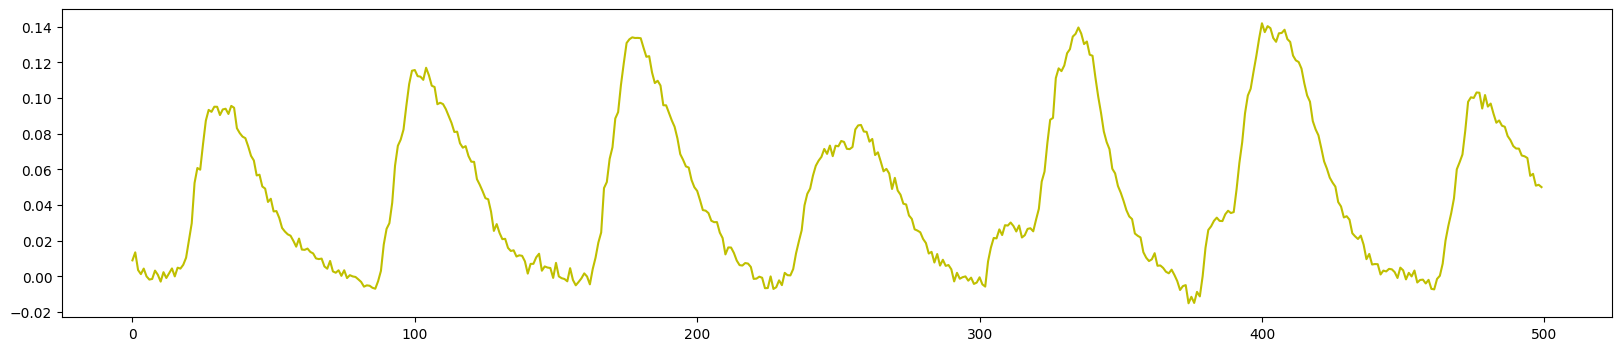

In [17]:
col = 80
y = df.iloc[:, col].values
y = calculate_dff(y)
y = y[:500]
plt.figure(figsize=(20, 4))
plt.plot(y, c='y')

In [ ]:
g_arr, sn = estimate_parameters(
    y,
    p=1,  # AR(1)
    range_ff=[0.25, 0.5],  # default
    method="median",  # mean or logmexp
    lags=10,
    fudge_factor=0.98,
)

c, s, b, g, lam = deconvolve(
    y,
    g=tuple(np.atleast_1d(g_arr)),
    sn=sn,
    penalty=1,  # L1 sparsity (standard OASIS)
    optimize_g=0,
)

/Users/fdrgsp/Documents/git/cali/.venv/lib/python3.12/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


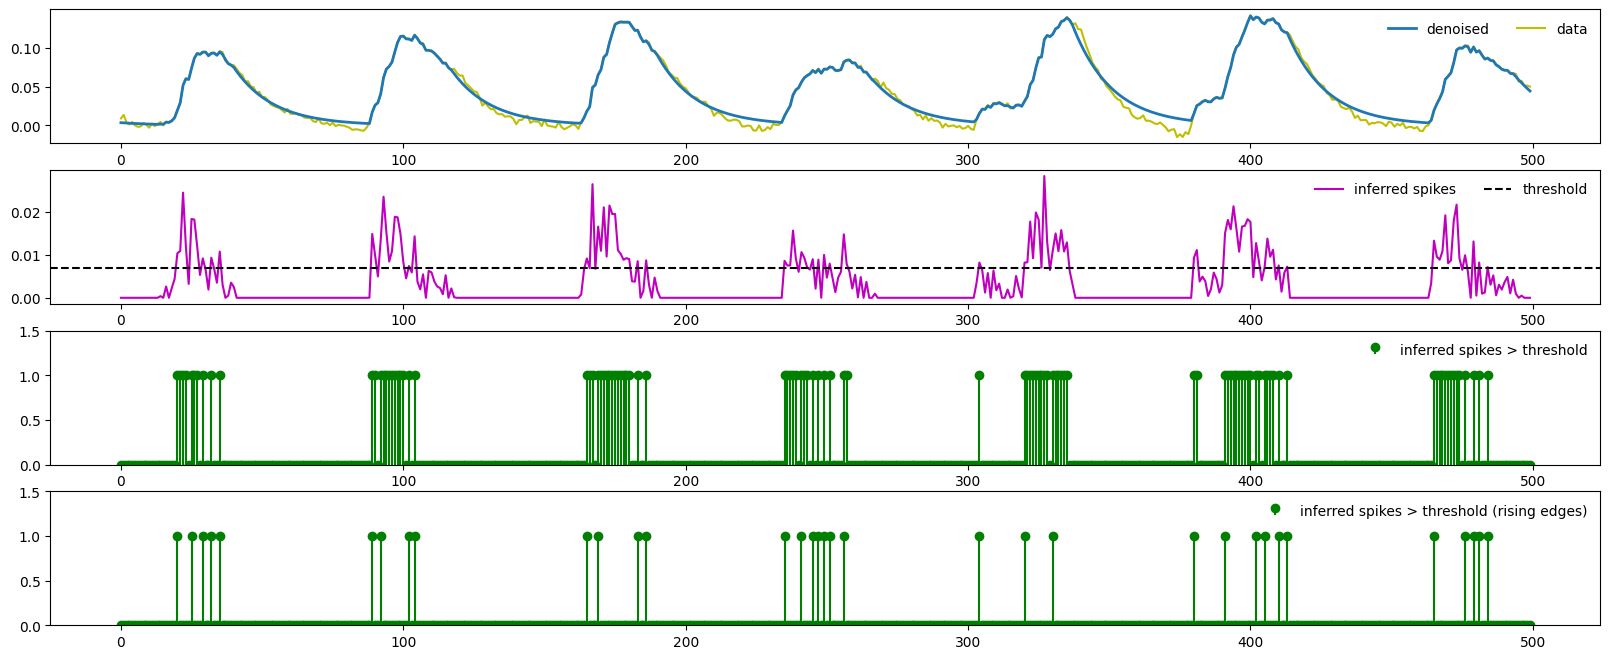

In [20]:
plot_trace(y, b, c, s, thr=sn * 3)